In [1]:
import pandas as pd
import re


df_linkedin = pd.read_csv("linkedin_with_salaries.csv")
df_ai_populated = pd.read_csv("ai_jobs_india_populated.csv")

combined_df = pd.concat([df_linkedin, df_ai_populated], ignore_index=True)

def clean_salary(val, edge="mid"):
    if pd.isna(val): return None
    nums = re.findall(r'\d+', str(val))
    if len(nums) >= 2:
        low, high = float(nums[0]), float(nums[1])
        if edge == "low": return low
        if edge == "high": return high
        return (low + high) / 2
    elif len(nums) == 1:
        return float(nums[0])
    return None

combined_df['Min_LPA'] = combined_df['salary'].apply(lambda x: clean_salary(x, "low"))
combined_df['Max_LPA'] = combined_df['salary'].apply(lambda x: clean_salary(x, "high"))
combined_df['Mid_LPA'] = combined_df['salary'].apply(lambda x: clean_salary(x, "mid"))
combined_df.to_csv("master_ai_jobs_india.csv", index=False)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv("master_ai_jobs_india.csv")
    print("Master dataset successfully loaded!")
    print(f"Total Job Postings: {df.shape[0]}")
except FileNotFoundError:
    print("Error: 'master_ai_jobs_india.csv' not found. Ensure the previous script ran successfully.")
    exit()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
title_col = next((col for col in df.columns if 'title' in col.lower() or 'role' in col.lower()), None)
loc_col = next((col for col in df.columns if 'loc' in col.lower() or 'city' in col.lower()), None)
comp_col = next((col for col in df.columns if 'comp' in col.lower() or 'org' in col.lower()), None)

print("\n--- Detected Columns for Analysis ---")
print(f"Job Title Column: {title_col}")
print(f"Location Column: {loc_col}")
print(f"Company Column: {comp_col}")


--- Detected Columns for Analysis ---
Job Title Column: title
Location Column: location
Company Column: company


In [ ]:
print("\n--- Salary Descriptive Statistics (LPA) ---")
salary_stats = df[['Min_LPA', 'Max_LPA', 'Mid_LPA']].describe()
print(salary_stats)


--- Salary Descriptive Statistics (LPA) ---
          Min_LPA     Max_LPA     Mid_LPA
count  429.000000  429.000000  429.000000
mean     9.745921   20.193473   14.969697
std      6.971120   11.287755    9.001117
min      4.000000    7.000000    5.500000
25%      6.000000   12.000000    9.500000
50%      7.000000   19.000000   13.000000
75%     10.000000   23.000000   18.000000
max     33.000000   58.000000   45.500000


c:\Users\hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


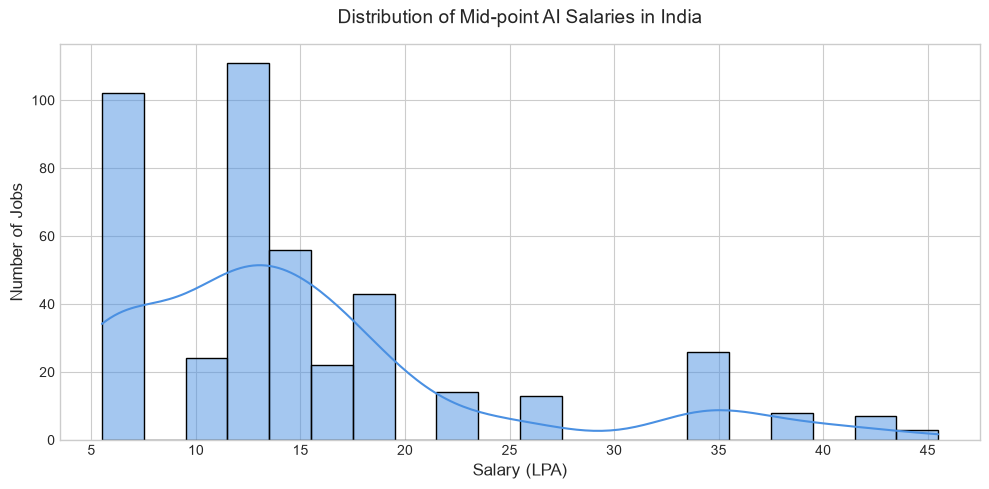

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Mid_LPA'].dropna(), kde=True, color='#4A90E2', bins=20, ax=ax)
ax.set_title('Distribution of Mid-point AI Salaries in India', fontsize=14, pad=15)
ax.set_xlabel('Salary (LPA)', fontsize=12)
ax.set_ylabel('Number of Jobs', fontsize=12)
plt.tight_layout()
plt.show()


--- Top 10 Most Frequent AI Job Titles ---
title
Data Scientist                 46
AI Engineer                    18
Machine Learning Engineer      13
Senior Data Scientist          12
Forward Deployed Engineer       7
AI/ML Engineer                  6
Software Engineer               6
Consultant - Data Scientist     5
Senior AI Engineer - Remote     5
Data Scientist | Remote         5
Name: count, dtype: int64

--- Top 10 Highest Paying AI Job Titles (Average Mid_LPA) ---
                           title  count      mean
             Lead Data Scientist      4 34.500000
             Senior LLM Engineer      3 25.500000
Senior Machine Learning Engineer      3 22.000000
 Staff Machine Learning Engineer      3 20.666667
           Senior Data Scientist     12 17.750000
       Forward Deployed Engineer      7 15.000000
     Consultant - Data Scientist      5 14.600000
               Software Engineer      6 14.416667
             Software Engineer I      3 13.833333
         Data Scienti

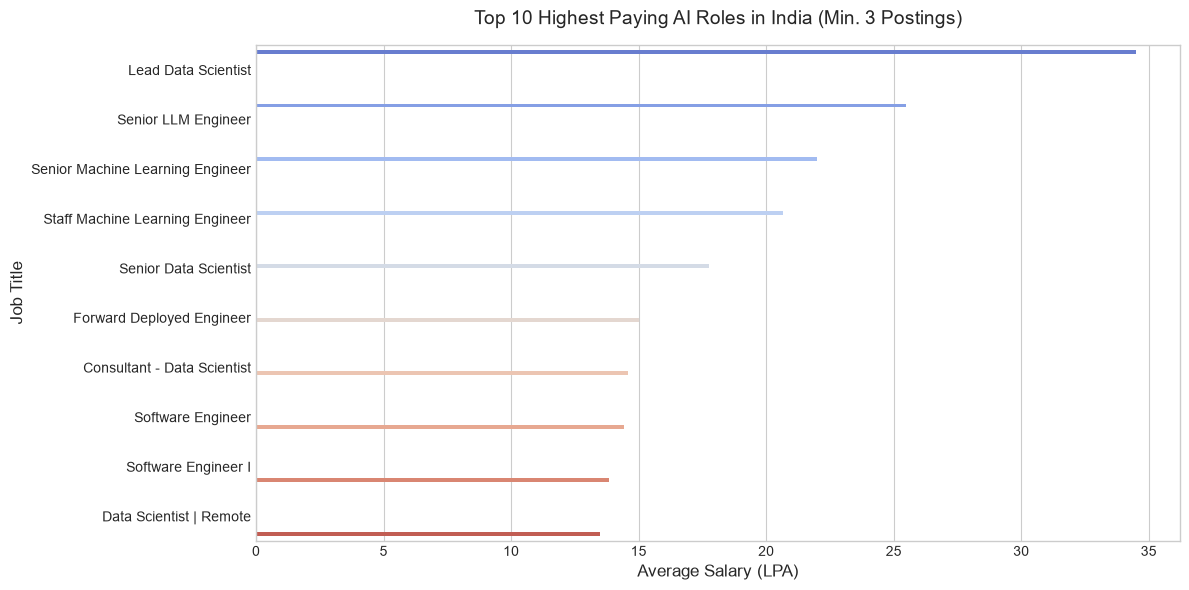

In [ ]:
if title_col:
    print(f"\n--- Top 10 Most Frequent AI Job Titles ---")
    print(df[title_col].value_counts().head(10))
    
    # Calculate highest paying job titles on average (filtering for roles with at least 3 occurrences)
    role_groups = df.groupby(title_col)['Mid_LPA'].agg(['count', 'mean']).reset_index()
    highest_paying_roles = role_groups[role_groups['count'] >= 3].sort_values(by='mean', ascending=False).head(10)
    
    print(f"\n--- Top 10 Highest Paying AI Job Titles (Average Mid_LPA) ---")
    print(highest_paying_roles.to_string(index=False))
    
    # 1. Initialize the plot layout
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 2. Render the barplot (Removed 'legend=False' to avoid compatibility crashes)
    sns.barplot(data=highest_paying_roles, x='mean', y=title_col, hue=title_col, palette='coolwarm', ax=ax)
    
    # 3. Clean up the legend if your older Seaborn version draws a redundant one
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    # 4. Label styling
    ax.set_title('Top 10 Highest Paying AI Roles in India (Min. 3 Postings)', fontsize=14, pad=15)
    ax.set_xlabel('Average Salary (LPA)', fontsize=12)
    ax.set_ylabel('Job Title', fontsize=12)
    
    # 5. Fit elements cleanly inside the figure frame
    plt.tight_layout()
    
    # 6. Show the chart instantly on-screen!
    plt.show()


--- Top 10 Job Locations by Demand ---
location
KA, IN                         70
Bengaluru, Karnataka, India    63
MH, IN                         34
TS, IN                         30
UP, IN                         22
Remote, IN                     16
Chennai, Tamil Nadu, India     16
TN, IN                         16
HR, IN                         15
Hyderabad, Telangana, India    15
Name: count, dtype: int64

--- Average AI Salary Across Top Locations ---
                         location  count      mean
                           HR, IN     15 20.133333
                           TS, IN     30 19.266667
                           TN, IN     16 17.906250
                               IN      5 16.700000
                           MH, IN     34 16.191176
          Gurgaon, Haryana, India      6 15.666667
                           UP, IN     22 15.500000
Pune Division, Maharashtra, India      8 15.500000
      Bengaluru, Karnataka, India     63 14.761905
                           

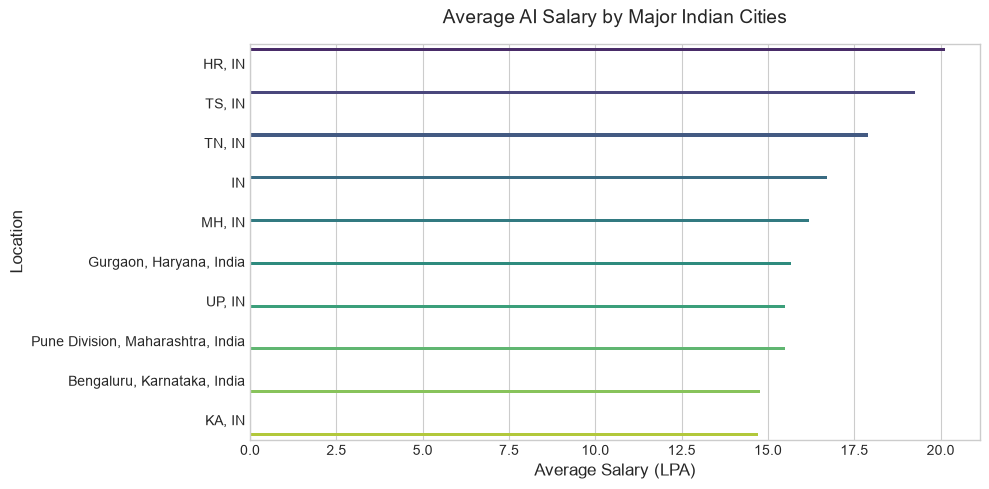

In [ ]:
if loc_col:
    print(f"\n--- Top 10 Job Locations by Demand ---")
    print(df[loc_col].value_counts().head(10))
    
    # Average salary per location
    loc_groups = df.groupby(loc_col)['Mid_LPA'].agg(['count', 'mean']).reset_index()
    top_paying_locations = loc_groups[loc_groups['count'] >= 5].sort_values(by='mean', ascending=False).head(10)
    
    print(f"\n--- Average AI Salary Across Top Locations ---")
    print(top_paying_locations.to_string(index=False))
    
    # 1. Initialize the plot layout
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 2. Render the barplot (using hue dynamically to match the updated Seaborn format)
    sns.barplot(data=top_paying_locations, x='mean', y=loc_col, hue=loc_col, palette='viridis', ax=ax)
    
    # 3. Handle and remove redundant legends safely across older Seaborn environments
    if ax.get_legend() is not None:
        ax.get_legend().remove()
        
    # 4. Label styling
    ax.set_title('Average AI Salary by Major Indian Cities', fontsize=14, pad=15)
    ax.set_xlabel('Average Salary (LPA)', fontsize=12)
    ax.set_ylabel('Location', fontsize=12)
    
    # 5. Fit elements cleanly inside the figure frame
    plt.tight_layout()
    
    # 6. Show the chart instantly on-screen!
    plt.show()


--- Top 10 Companies Hiring for AI Roles ---
company
Genpact               16
Infosys               14
Accenture             10
EPAM Systems           9
Persistent Systems     8
HCLTech                8
Google                 7
Crossing Hurdles       6
Deloitte               6
Amgen                  6
Name: count, dtype: int64

--- Highest Paying Companies (Min. 2 Postings) ---
               company  count      mean
                AXTRIA      2 40.000000
Warner Bros. Discovery      2 31.500000
              DocuSign      2 28.250000
                    EY      2 26.750000
          EPAM Systems      9 25.055556
               HCLTech      8 24.937500
                  Citi      2 23.750000
                 Amgen      6 23.666667
                Dentsu      3 23.333333
            SymphonyAI      2 23.000000


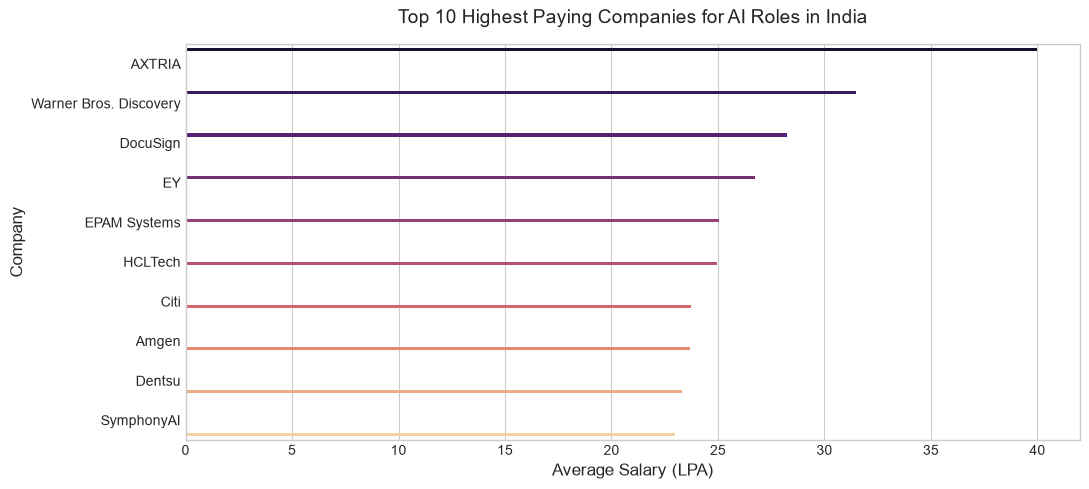

In [ ]:
if comp_col:
    print(f"\n--- Top 10 Companies Hiring for AI Roles ---")
    print(df[comp_col].value_counts().head(10))
    
    # Top paying companies
    comp_groups = df.groupby(comp_col)['Mid_LPA'].agg(['count', 'mean']).reset_index()
    top_paying_companies = comp_groups[comp_groups['count'] >= 2].sort_values(by='mean', ascending=False).head(10)
    
    print(f"\n--- Highest Paying Companies (Min. 2 Postings) ---")
    print(top_paying_companies.to_string(index=False))
    
    # 1. Initialize the plot layout
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(11, 5))
    
    # 2. Render the barplot using the vibrant 'magma' color palette
    sns.barplot(data=top_paying_companies, x='mean', y=comp_col, hue=comp_col, palette='magma', ax=ax)
    
    # 3. Prevent duplicate legend bugs on older Anaconda installations
    if ax.get_legend() is not None:
        ax.get_legend().remove()
        
    # 4. Label styling
    ax.set_title('Top 10 Highest Paying Companies for AI Roles in India', fontsize=14, pad=15)
    ax.set_xlabel('Average Salary (LPA)', fontsize=12)
    ax.set_ylabel('Company', fontsize=12)
    
    # 5. Prevent text clipping around the borders
    plt.tight_layout()
    
    # 6. Show the chart instantly on-screen!
    plt.show()

--- Top 10 Companies with the Most Openings in Your Data ---
company
Genpact               16
Infosys               14
Accenture             10
EPAM Systems           9
Persistent Systems     8
HCLTech                8
Google                 7
Crossing Hurdles       6
Deloitte               6
Amgen                  6
Name: count, dtype: int64


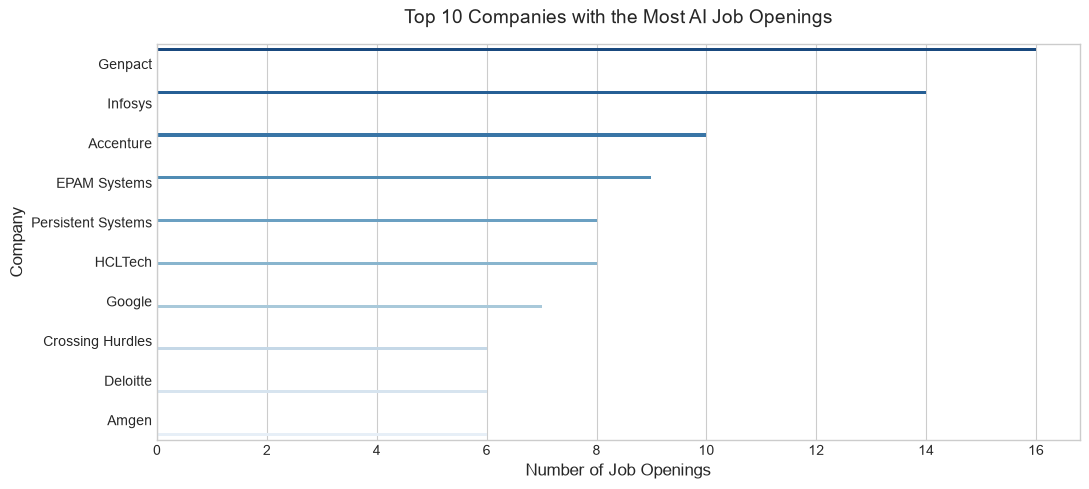

In [ ]:
if comp_col:
    print("--- Top 10 Companies with the Most Openings in Your Data ---")
    top_counts = df[comp_col].value_counts().head(10)
    print(top_counts)
    
    # Convert the series data to a dataframe structure for plotting
    top_companies_df = top_counts.reset_index()
    top_companies_df.columns = ['Company', 'Job Count']
    
    # 1. Initialize the plot layout
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(11, 5))
    
    # 2. Render horizontal bars using a sequential gradient palette ('Blues_r')
    sns.barplot(data=top_companies_df, x='Job Count', y='Company', hue='Company', palette='Blues_r', ax=ax)
    
    # 3. Suppress redundant legend layouts
    if ax.get_legend() is not None:
        ax.get_legend().remove()
        
    # 4. Label styling
    ax.set_title('Top 10 Companies with the Most AI Job Openings', fontsize=14, pad=15)
    ax.set_xlabel('Number of Job Openings', fontsize=12)
    ax.set_ylabel('Company', fontsize=12)
    
    # 5. Clean layout boundary matching
    plt.tight_layout()
    
    # 6. Show the chart instantly on-screen!
    plt.show()